In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

C:\Users\Johnny\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)
ogdf = pd.read_csv(f"{path}/CAR DETAILS FROM CAR DEKHO.csv")
df = ogdf.copy()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# Dataset 1 - Vehicle dataset
by John Lopes

## Description

"This dataset contains information about used cars.
This data can be used for a lot of purposes such as price prediction to exemplify the use of linear regression in Machine Learning."

key features:
1. name
2. year
3. selling_price
4. km_driven
5. fuel
6. seller_type
7. transmission
8. Owner

## Code

## a)

### b)

In [3]:
#did not encode the name column due to unique values
dfEncoded = pd.get_dummies(df, columns=['fuel', 'transmission', 'owner', 'seller_type'], drop_first=True)
#print(df["fuel"])
#print(dfEncoded["fuel_Diesel"])

## c) -clean up later

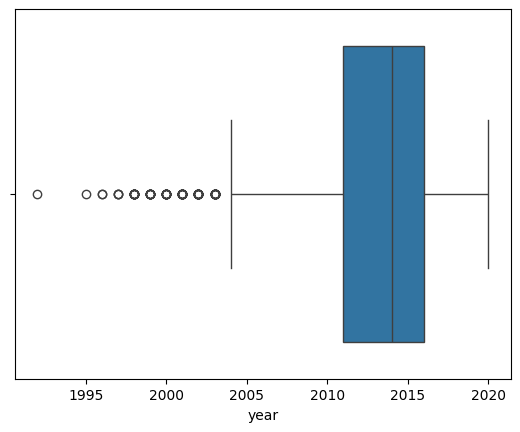

In [4]:
yearPlot = sns.boxplot(df,x="year")

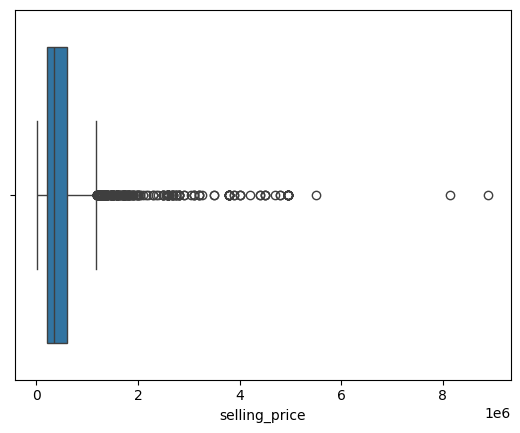

In [5]:
sellingPrice = sns.boxplot(df,x="selling_price")

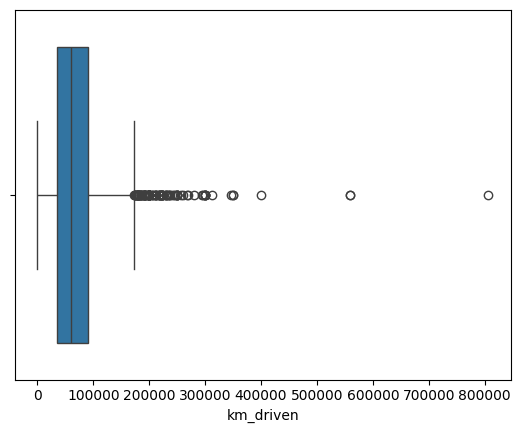

In [6]:
kmDriven = sns.boxplot(df,x="km_driven")

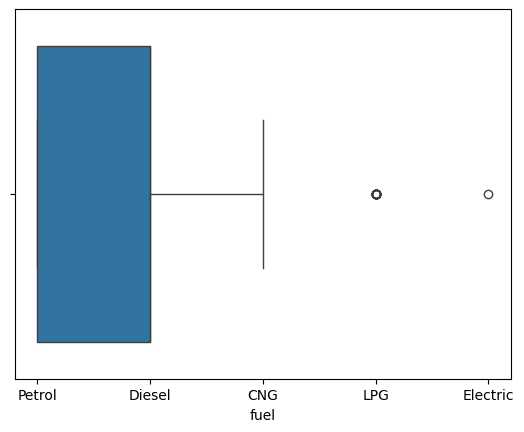

In [7]:
fuelPlot = sns.boxplot(df,x="fuel")

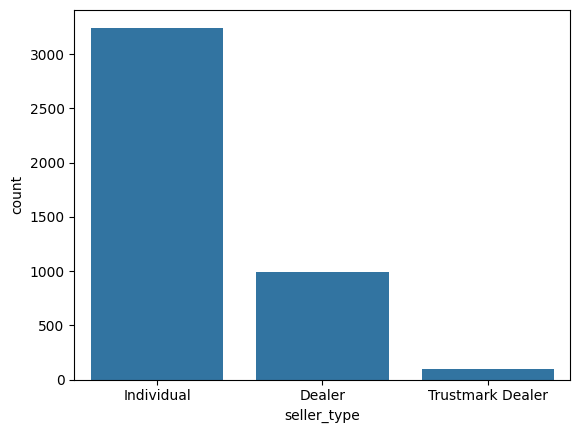

In [8]:
sellerPlot = sns.countplot(df,x="seller_type")

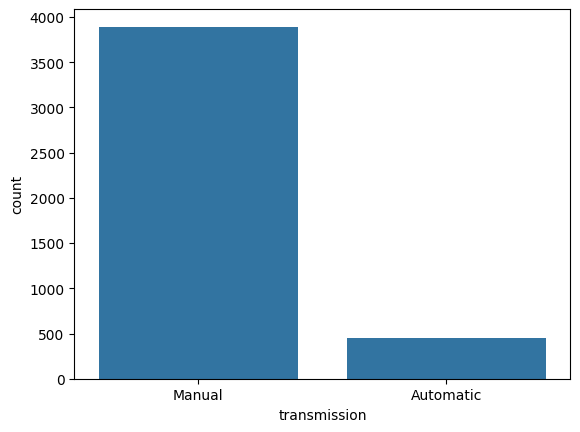

In [9]:
transmissionPlot = sns.countplot(df,x="transmission")

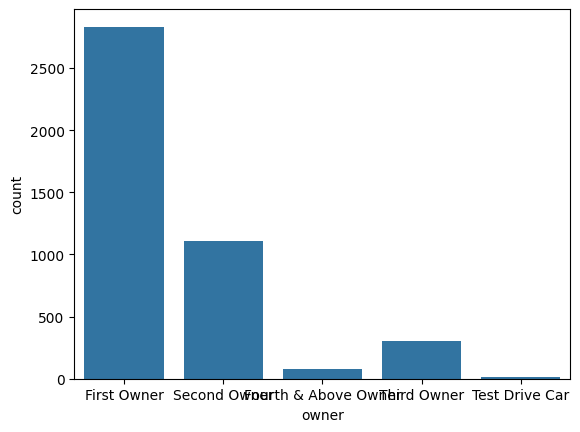

In [10]:
ownerPlot = sns.countplot(df,x="owner")

In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

cols = ['year', 'selling_price', 'km_driven']
# fit and predict; -1 means outlier
df['lof_label'] = lof.fit_predict(df[cols])
df['lof_score'] = lof.negative_outlier_factor_

#df[df['lof_label'] == -1].head()

In [12]:
print(df[df["lof_label"]==-1])
#removing outliers
df = df[df["lof_label"]!=-1]
print(df[df["lof_label"]==-1])

                                                   name  year  selling_price  \
32                                      Audi Q5 2.0 TDI  2011        1190000   
56                          Hyundai i20 Sportz 1.4 CRDi  2018         750000   
57    Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...  2018         310000   
69        Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII  2010         280000   
70                     Toyota Corolla Altis Diesel D4DG  2011         350000   
...                                                 ...   ...            ...   
4282                            Maruti Wagon R LX Minor  2013         290000   
4294                          Mahindra XUV500 AT W8 FWD  2015         740000   
4326                                 Honda City 1.5 GXI  2005          65000   
4331               Ford EcoSport 1.5 TDCi Titanium BSIV  2015         530000   
4334       Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV  2012         600000   

      km_driven    fuel seller_type tra

## d)

## e)

## f)

## g)

## References

https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html